In [ ]:
!pip install kaggle -q

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mohosiulhaquealvi","key":"b915189c96ef8c2e2b532d610ebc3b63"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d rileykeifer/multichannel-glaucoma-benchmark-dataset
!unzip -q multichannel-glaucoma-benchmark-dataset.zip -d /content/glaucoma_dataset

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open multichannel-glaucoma-benchmark-dataset.zip, multichannel-glaucoma-benchmark-dataset.zip.zip or multichannel-glaucoma-benchmark-dataset.zip.ZIP.


In [ ]:
!kaggle datasets download -d deathtrooper/multichannel-glaucoma-benchmark-dataset

Dataset URL: https://www.kaggle.com/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset
License(s): other
100% 2.93G/2.93G [00:34<00:00, 91.9MB/s]



In [ ]:
!unzip -q multichannel-glaucoma-benchmark-dataset.zip -d /content/glaucoma_dataset

import os
print(os.listdir("/content/glaucoma_dataset"))

['optic-cup', 'vessel-artery', 'spectral-oct-disc', 'optic-disc', 'metadata - standardized.csv', 'vessel-vein', 'blood-vessel', 'spectral-oct-cup', 'spectral-oct', 'full-fundus']


In [ ]:
import os

base_path = "/content/glaucoma_dataset"

for root, dirs, files in os.walk(base_path):
    print(root)
    break

/content/glaucoma_dataset


In [ ]:
full_fundus_path = "/content/glaucoma_dataset/full-fundus"
print(len(os.listdir(full_fundus_path)))

1


In [ ]:
import os

full_fundus_path = "/content/glaucoma_dataset/full-fundus"

print(os.listdir(full_fundus_path))

['full-fundus']


In [ ]:
for root, dirs, files in os.walk(full_fundus_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:10])
    print("FILES:", files[:10])
    print("FILE COUNT:", len(files))
    break

ROOT: /content/glaucoma_dataset/full-fundus
DIRS: ['full-fundus']
FILES: []
FILE COUNT: 0


In [ ]:
full_fundus_path = "/content/glaucoma_dataset/full-fundus/full-fundus"

In [ ]:
import os

print(len(os.listdir(full_fundus_path)))
print(os.listdir(full_fundus_path)[:10])

12449
['BEH-255.png', 'PAPILA-485.png', 'OIA-ODIR-TEST-OFFLINE-149.png', 'BEH-263.png', 'EyePACS-Glaucoma-608.png', 'OIA-ODIR-TEST-OFFLINE-236.png', 'OIA-ODIR-TEST-OFFLINE-169.png', 'OIA-ODIR-TRAIN-2521.png', 'EyePACS-Glaucoma-3258.png', 'OIA-ODIR-TRAIN-2353.png']


In [ ]:
import pandas as pd

csv_path = "/content/glaucoma_dataset/metadata - standardized.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)

                     names  types type_expanded  isColor   original_name  \
0  OIA-ODIR-TEST-OFFLINE-1      0           NaN        1  1029_right.jpg   
1  OIA-ODIR-TEST-OFFLINE-2      0           NaN        1   1049_left.jpg   
2  OIA-ODIR-TEST-OFFLINE-4      0           NaN        1   1128_left.jpg   
3  OIA-ODIR-TEST-OFFLINE-5      0           NaN        1  1179_right.jpg   
4  OIA-ODIR-TEST-OFFLINE-6      0           NaN        1   1180_left.jpg   

  patient_id                                    fundus fundus_od_seg  \
0        NaN  /full-fundus/OIA-ODIR-TEST-OFFLINE-1.png           NaN   
1        NaN  /full-fundus/OIA-ODIR-TEST-OFFLINE-2.png           NaN   
2        NaN  /full-fundus/OIA-ODIR-TEST-OFFLINE-4.png           NaN   
3        NaN  /full-fundus/OIA-ODIR-TEST-OFFLINE-5.png           NaN   
4        NaN  /full-fundus/OIA-ODIR-TEST-OFFLINE-6.png           NaN   

  fundus_oc_seg bv_seg  ... cdr_expert4 refractive_dioptre_1  \
0           NaN    NaN  ...         NaN       

In [ ]:
print(df.head(10))
print("\nCOLUMNS:\n", df.columns.tolist())

                      names  types type_expanded  isColor   original_name  \
0   OIA-ODIR-TEST-OFFLINE-1      0           NaN        1  1029_right.jpg   
1   OIA-ODIR-TEST-OFFLINE-2      0           NaN        1   1049_left.jpg   
2   OIA-ODIR-TEST-OFFLINE-4      0           NaN        1   1128_left.jpg   
3   OIA-ODIR-TEST-OFFLINE-5      0           NaN        1  1179_right.jpg   
4   OIA-ODIR-TEST-OFFLINE-6      0           NaN        1   1180_left.jpg   
5   OIA-ODIR-TEST-OFFLINE-7      0           NaN        1  1184_right.jpg   
6   OIA-ODIR-TEST-OFFLINE-8      0           NaN        1   1192_left.jpg   
7   OIA-ODIR-TEST-OFFLINE-9      0           NaN        1  1193_right.jpg   
8  OIA-ODIR-TEST-OFFLINE-10      0           NaN        1   1199_left.jpg   
9  OIA-ODIR-TEST-OFFLINE-11      0           NaN        1   1244_left.jpg   

  patient_id                                     fundus fundus_od_seg  \
0        NaN   /full-fundus/OIA-ODIR-TEST-OFFLINE-1.png           NaN   
1     

In [ ]:
import pandas as pd

df = pd.read_csv("/content/glaucoma_dataset/metadata - standardized.csv")

# Keep only needed columns
df = df[['fundus', 'types']]


df = df.dropna()

# Convert label to int
df['types'] = df['types'].astype(int)

print(df.head())
print(df['types'].value_counts())

                                     fundus  types
0  /full-fundus/OIA-ODIR-TEST-OFFLINE-1.png      0
1  /full-fundus/OIA-ODIR-TEST-OFFLINE-2.png      0
2  /full-fundus/OIA-ODIR-TEST-OFFLINE-4.png      0
3  /full-fundus/OIA-ODIR-TEST-OFFLINE-5.png      0
4  /full-fundus/OIA-ODIR-TEST-OFFLINE-6.png      0
types
 0    7549
 1    4767
-1     133
Name: count, dtype: int64


In [ ]:
import os

# Keep only normal and glaucoma labels
df = df[df['types'].isin([0, 1])].copy()

# Create real image path
df['image_path'] = df['fundus'].apply(
    lambda x: "/content/glaucoma_dataset/full-fundus" + x
)

# Check if files exist
df['exists'] = df['image_path'].apply(os.path.exists)

print(df.head())
print(df['types'].value_counts())
print("Existing images:", df['exists'].sum(), "out of", len(df))

                                     fundus  types  \
0  /full-fundus/OIA-ODIR-TEST-OFFLINE-1.png      0   
1  /full-fundus/OIA-ODIR-TEST-OFFLINE-2.png      0   
2  /full-fundus/OIA-ODIR-TEST-OFFLINE-4.png      0   
3  /full-fundus/OIA-ODIR-TEST-OFFLINE-5.png      0   
4  /full-fundus/OIA-ODIR-TEST-OFFLINE-6.png      0   

                                          image_path  exists  
0  /content/glaucoma_dataset/full-fundus/full-fun...    True  
1  /content/glaucoma_dataset/full-fundus/full-fun...    True  
2  /content/glaucoma_dataset/full-fundus/full-fun...    True  
3  /content/glaucoma_dataset/full-fundus/full-fun...    True  
4  /content/glaucoma_dataset/full-fundus/full-fun...    True  
types
0    7549
1    4767
Name: count, dtype: int64
Existing images: 12316 out of 12316


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 128  # keep small for speed

images = []
labels = []

for i, row in df.iterrows():
    img_path = row['image_path']

    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    images.append(img)
    labels.append(row['types'])

    # limit for speed (IMPORTANT for now)
    if len(images) >= 2000:
        break

X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 128, 128, 3)
y shape: (2000,)


In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Train: (1600, 128, 128, 3) (1600,)
Test: (400, 128, 128, 3) (400,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,763,521 (60.13 MB)

 Trainable params: 1,048,833 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 366s 9s/step - accuracy: 0.8586 - loss: 0.4917 - val_accuracy: 0.8562 - val_loss: 0.3707
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 351s 9s/step - accuracy: 0.8742 - loss: 0.3489 - val_accuracy: 0.8562 - val_loss: 0.3568
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 390s 9s/step - accuracy: 0.8734 - loss: 0.3354 - val_accuracy: 0.8562 - val_loss: 0.3434
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 366s 9s/step - accuracy: 0.8734 - loss: 0.3163 - val_accuracy: 0.8562 - val_loss: 0.3354
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 376s 9s/step - accuracy: 0.8734 - loss: 0.3127 - val_accuracy: 0.8562 - val_loss: 0.4032


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Healthy", "Glaucoma"]))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 98s 7s/step
Test Accuracy: 0.5

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.50      1.00      0.67       200
    Glaucoma       0.00      0.00      0.00       200

    accuracy                           0.50       400
   macro avg       0.25      0.50      0.33       400
weighted avg       0.25      0.50      0.33       400


Confusion Matrix:

[[200   0]
 [200   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import cv2
import numpy as np
import pandas as pd
import os

IMG_SIZE = 128
SAMPLES_PER_CLASS = 1000

df_0 = df[df['types'] == 0].sample(SAMPLES_PER_CLASS, random_state=42)
df_1 = df[df['types'] == 1].sample(SAMPLES_PER_CLASS, random_state=42)

df_balanced = pd.concat([df_0, df_1]).sample(frac=1, random_state=42).reset_index(drop=True)

images = []
labels = []

for _, row in df_balanced.iterrows():
    img = cv2.imread(row['image_path'])
    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    images.append(img)
    labels.append(row['types'])

X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(pd.Series(y).value_counts())

X shape: (2000, 128, 128, 3)
y shape: (2000,)
1    1000
0    1000
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
import cv2
import numpy as np
import pandas as pd

IMG_SIZE = 224
SAMPLES_PER_CLASS = 1000

df_0 = df[df['types'] == 0].sample(SAMPLES_PER_CLASS, random_state=42)
df_1 = df[df['types'] == 1].sample(SAMPLES_PER_CLASS, random_state=42)

df_balanced = pd.concat([df_0, df_1]).sample(frac=1, random_state=42).reset_index(drop=True)

images = []
labels = []

for _, row in df_balanced.iterrows():
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img.astype(np.float32))

    images.append(img)
    labels.append(row['types'])

X = np.array(images)
y = np.array(labels)

print(X.shape, y.shape)
print(pd.Series(y).value_counts())

(2000, 224, 224, 3) (2000,)
1    1000
0    1000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1600, 224, 224, 3) (400, 224, 224, 3)


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=32
)

Epoch 1/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 1120s 28s/step - accuracy: 0.7203 - loss: 0.5886 - val_accuracy: 0.7281 - val_loss: 0.5403
Epoch 2/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 1108s 28s/step - accuracy: 0.7664 - loss: 0.4931 - val_accuracy: 0.7281 - val_loss: 0.5038
Epoch 3/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 1110s 28s/step - accuracy: 0.7664 - loss: 0.4701 - val_accuracy: 0.7437 - val_loss: 0.4906


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Healthy", "Glaucoma"]))
print(confusion_matrix(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 266s 20s/step
Test Accuracy: 0.72
              precision    recall  f1-score   support

     Healthy       0.80      0.58      0.68       200
    Glaucoma       0.67      0.85      0.75       200

    accuracy                           0.72       400
   macro avg       0.74      0.72      0.71       400
weighted avg       0.74      0.72      0.71       400

[[117  83]
 [ 29 171]]


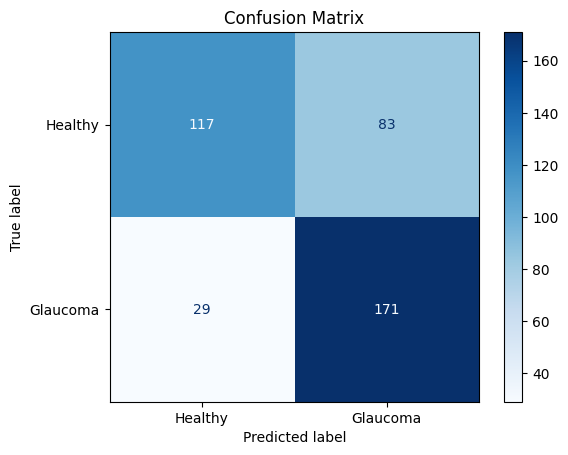

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Glaucoma"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

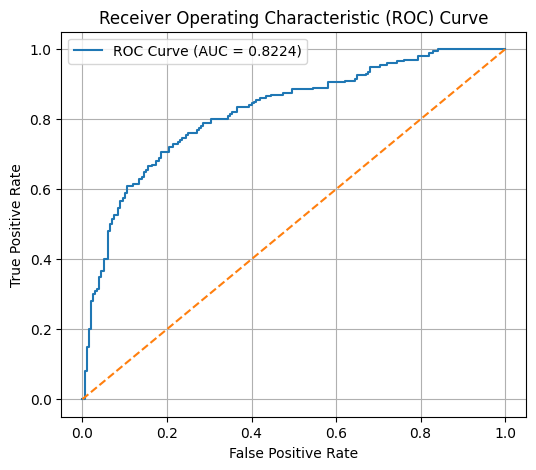

AUC: 0.8224499999999999


In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.show()

print("AUC:", roc_auc)

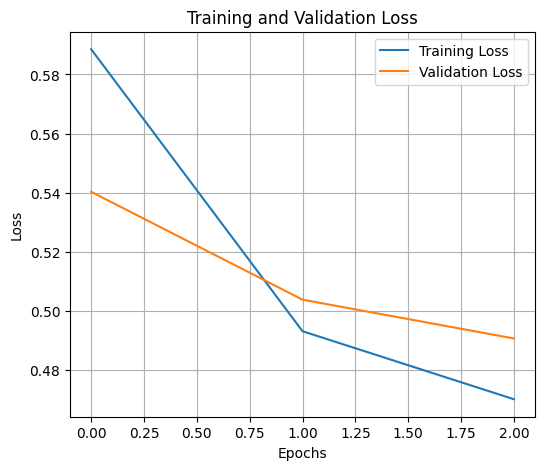

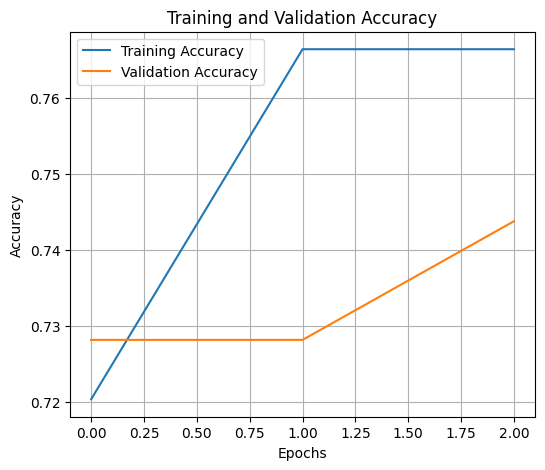

In [36]:
import matplotlib.pyplot as plt

# Loss graph
plt.figure(figsize=(6, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy graph
plt.figure(figsize=(6, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import zipfile
from google.colab import files

# 1. Loss graph
plt.figure(figsize=(6,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig("loss.png", bbox_inches="tight")
plt.close()

# 2. Accuracy graph
plt.figure(figsize=(6,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("accuracy.png", bbox_inches="tight")
plt.close()

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Glaucoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion.png", bbox_inches="tight")
plt.close()

# 4. ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig("roc.png", bbox_inches="tight")
plt.close()

# ZIP all images
with zipfile.ZipFile("glaucoma_results.zip", "w") as zipf:
    zipf.write("loss.png")
    zipf.write("accuracy.png")
    zipf.write("confusion.png")
    zipf.write("roc.png")

files.download("glaucoma_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>